In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, '..')

df = pd.read_csv('../results/raw/results.csv')
print(f"Total runs: {len(df)}")
print(f"Models: {df['model'].unique()}")
print(f"Datasets: {df['dataset'].unique()}")
df.head()

Total runs: 48
Models: ['XGBoost' 'LightGBM' 'CatBoost' 'RandomForest' 'TabPFN' 'TabICL']
Datasets: ['MI' 'BreastCancer']


,dataset,fold,train_size,model,auroc,auprc,brier,train_time,inf_time
0,MI,0,50,XGBoost,0.925890,0.842438,0.089389,0.494388,0.000004
1,MI,0,50,LightGBM,0.688433,0.326384,0.154072,0.091430,0.000002
2,MI,0,50,CatBoost,0.869730,0.676137,0.106606,0.505885,0.000001
3,MI,0,50,RandomForest,0.931193,0.829729,0.081382,0.560110,0.000154
4,MI,0,50,TabPFN,NaN,NaN,NaN,NaN,NaN


In [17]:
print('=== By Training Size (MI only) ===')
mi = df[df['dataset']=='MI']
print(mi.groupby(['train_size','model'])['auroc'].mean().round(3).unstack())

print('\n=== By Training Size (BreastCancer only) ===')
bc = df[df['dataset']=='BreastCancer']
print(bc.groupby(['train_size','model'])['auroc'].mean().round(3).unstack())

print('\n=== By Dataset (overall) ===')
print(df.groupby(['dataset','model'])['auroc'].mean().round(3).unstack())

=== By Training Size (MI only) ===
model       CatBoost  LightGBM  RandomForest  TabICL  TabPFN  XGBoost
train_size                                                           
50             0.823     0.699         0.916   0.948     NaN    0.865
626            0.948     0.957         0.960   0.966     NaN    0.960
627            0.934     0.936         0.936   0.956     NaN    0.939

=== By Training Size (BreastCancer only) ===
model       CatBoost  LightGBM  RandomForest  TabICL  TabPFN  XGBoost
train_size                                                           
50             0.978     0.977         0.985   0.987     NaN    0.977
284            0.989     0.992         0.988   0.998     NaN    0.993
285            0.991     0.987         0.988   0.996     NaN    0.987

=== By Dataset (overall) ===
model         CatBoost  LightGBM  RandomForest  TabICL  TabPFN  XGBoost
dataset                                                                
BreastCancer     0.984     0.983         0.98

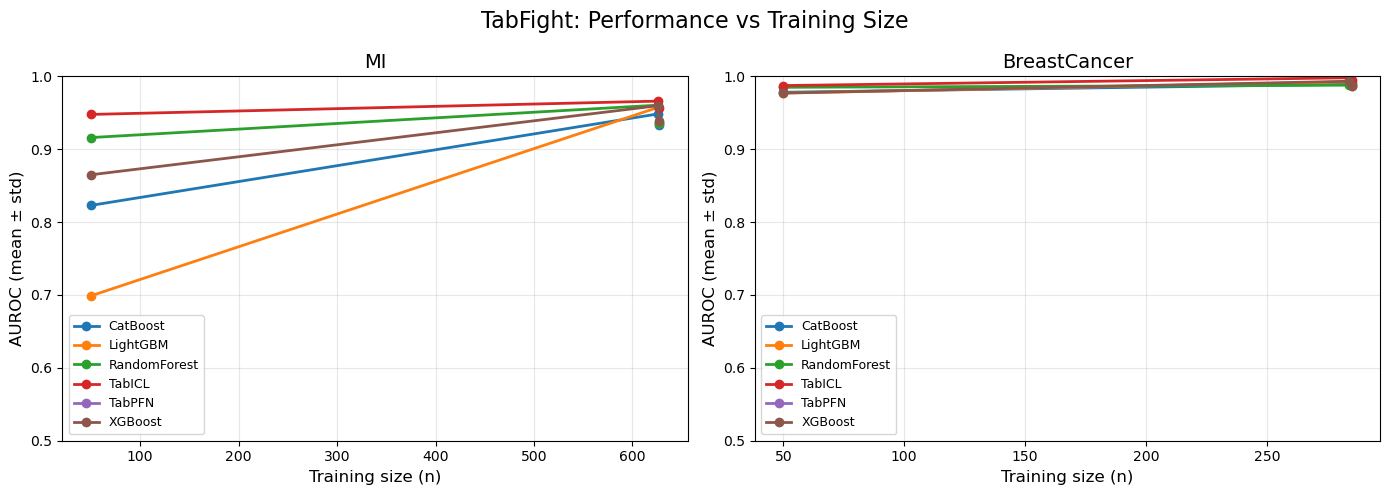

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dataset in zip(axes, ['MI', 'BreastCancer']):
    data = df[df['dataset'] == dataset]
    summary = data.groupby(['model', 'train_size']).agg(
        auroc_mean=('auroc', 'mean'),
        auroc_std=('auroc', 'std')
    ).reset_index()

    for model, group in summary.groupby('model'):
        group = group.sort_values('train_size')
        ax.plot(group['train_size'], group['auroc_mean'],
                marker='o', label=model, linewidth=2)
        ax.fill_between(
            group['train_size'],
            group['auroc_mean'] - group['auroc_std'],
            group['auroc_mean'] + group['auroc_std'],
            alpha=0.1
        )

    ax.set_xlabel('Training size (n)', fontsize=12)
    ax.set_ylabel('AUROC (mean ± std)', fontsize=12)
    ax.set_title(f'{dataset}', fontsize=14)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.5, 1.0)

plt.suptitle('TabFight: Performance vs Training Size', fontsize=16)
plt.tight_layout()
plt.savefig('../results/figures/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

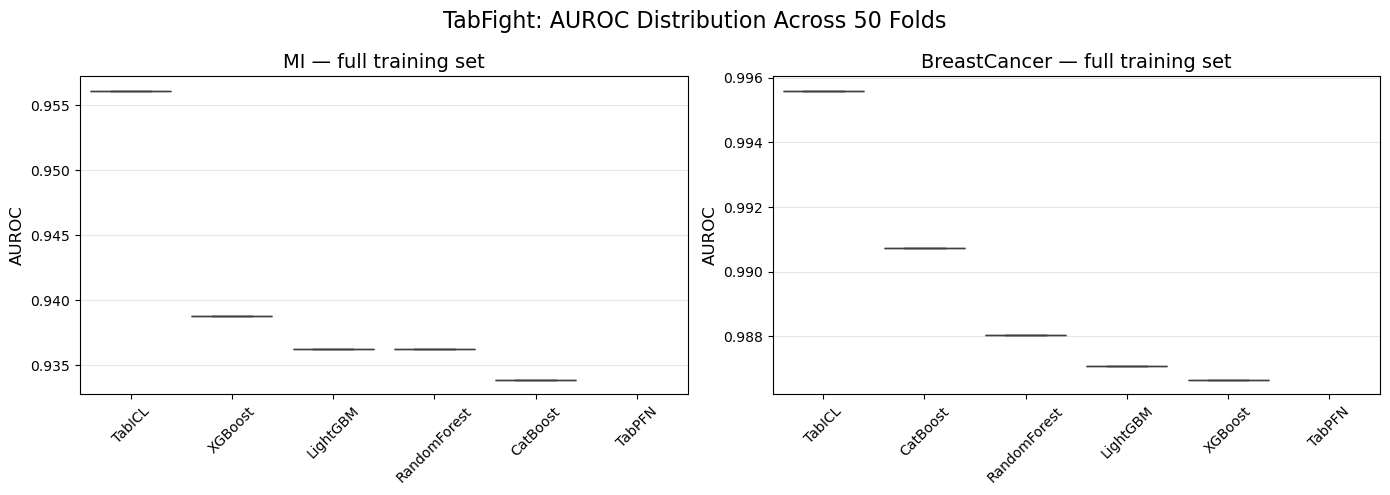

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dataset in zip(axes, ['MI', 'BreastCancer']):
    # use full training size only
    full_size = df[df['dataset'] == dataset]['train_size'].max()
    data = df[(df['dataset'] == dataset) & (df['train_size'] == full_size)]

    order = (data.groupby('model')['auroc']
             .median()
             .sort_values(ascending=False)
             .index)

    sns.boxplot(data=data, x='model', y='auroc', order=order, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('AUROC', fontsize=12)
    ax.set_title(f'{dataset} — full training set', fontsize=14)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('TabFight: AUROC Distribution Across 50 Folds', fontsize=16)
plt.tight_layout()
plt.savefig('../results/figures/boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
full_sizes = df.groupby('dataset')['train_size'].max().to_dict()

rows = []
for dataset, full_size in full_sizes.items():
    data = df[(df['dataset'] == dataset) & (df['train_size'] == full_size)]
    summary = data.groupby('model').agg(
        auroc_mean=('auroc', 'mean'),
        auroc_std=('auroc', 'std'),
        auprc_mean=('auprc', 'mean'),
        brier_mean=('brier', 'mean'),
        train_time=('train_time', 'mean'),
    ).reset_index()
    summary['dataset'] = dataset
    rows.append(summary)

table = pd.concat(rows)
table['AUROC'] = table.apply(lambda r: f"{r['auroc_mean']:.3f} ± {r['auroc_std']:.3f}", axis=1)
table['AUPRC'] = table['auprc_mean'].round(3)
table['Brier'] = table['brier_mean'].round(3)
table['Time(s)'] = table['train_time'].round(2)

print(table[['dataset', 'model', 'AUROC', 'AUPRC', 'Brier', 'Time(s)']].to_string(index=False))

     dataset        model       AUROC  AUPRC  Brier  Time(s)
BreastCancer     CatBoost 0.991 ± nan  0.987  0.040     0.54
BreastCancer     LightGBM 0.987 ± nan  0.983  0.048     0.05
BreastCancer RandomForest 0.988 ± nan  0.981  0.043     0.53
BreastCancer       TabICL 0.996 ± nan  0.994  0.020     0.28
BreastCancer       TabPFN   nan ± nan    NaN    NaN      NaN
BreastCancer      XGBoost 0.987 ± nan  0.983  0.046     0.14
          MI     CatBoost 0.934 ± nan  0.849  0.075     0.29
          MI     LightGBM 0.936 ± nan  0.866  0.073     0.07
          MI RandomForest 0.936 ± nan  0.858  0.072     0.58
          MI       TabICL 0.956 ± nan  0.878  0.067     0.27
          MI       TabPFN   nan ± nan    NaN    NaN      NaN
          MI      XGBoost 0.939 ± nan  0.868  0.073     0.14


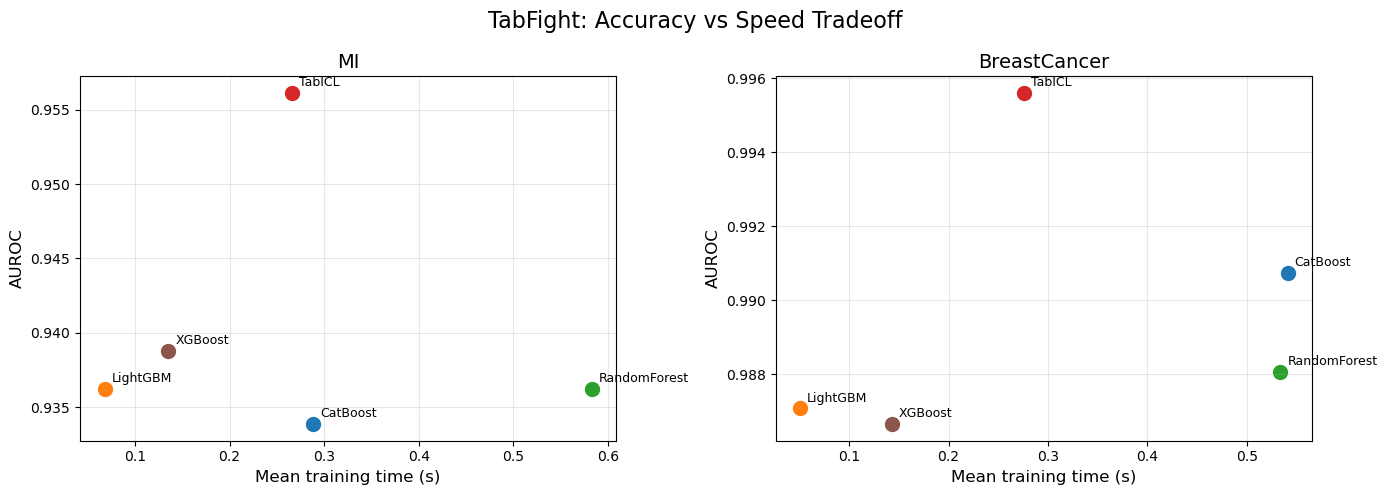

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dataset in zip(axes, ['MI', 'BreastCancer']):
    full_size = df[df['dataset'] == dataset]['train_size'].max()
    data = df[(df['dataset'] == dataset) & (df['train_size'] == full_size)]
    summary = data.groupby('model').agg(
        auroc_mean=('auroc', 'mean'),
        train_time_mean=('train_time', 'mean')
    ).reset_index()

    for _, row in summary.iterrows():
        ax.scatter(row['train_time_mean'], row['auroc_mean'], s=100)
        ax.annotate(row['model'],
                   (row['train_time_mean'], row['auroc_mean']),
                   textcoords='offset points', xytext=(5, 5), fontsize=9)

    ax.set_xlabel('Mean training time (s)', fontsize=12)
    ax.set_ylabel('AUROC', fontsize=12)
    ax.set_title(f'{dataset}', fontsize=14)
    ax.grid(True, alpha=0.3)

plt.suptitle('TabFight: Accuracy vs Speed Tradeoff', fontsize=16)
plt.tight_layout()
plt.savefig('../results/figures/efficiency.png', dpi=150, bbox_inches='tight')
plt.show()